Лабораторная работа №3. Линейная регрессия
Общее задание
Перед выполнением лабораторной работы необходимо загрузить набор данных в соответствии с вариантом на диск

1.Написать программу, которая разделяет исходную выборку на обучающую и тестовую (training set, test set). Использовать стандартные функции (train_test_split и др. нельзя).

2. С использованием библиотеки scikit-learn обучить модель линейной регрессии по обучающей выборке пример

3. Проверить точность модели по тестовой выборке

4. Построить модель с использованием полиномиальной функции пример. Построить графики зависимости точности на обучающей и тестовой выборке от степени полиномиальной функции.

5. Построить модель с использованием регуляризации пример. На основе экспериментов подобрать параметры для регуляризации. Построить графики зависимости точности модели на обучающей и тестовой выборках от коэффициента регуляризации.

In [13]:
from sklearn.preprocessing import PolynomialFeatures

print("Лабораторная работа 3. 'Линейная регрессия'\n Выполнил студент группы ИВТИИбд-31 Бугров Данила")

Лабораторная работа 3. 'Линейная регрессия'
 Выполнил студент группы ИВТИИбд-31 Бугров Данила


1.Разделим выборку на обучающую и тестовую:

Для начала считаем данные из датасета slump_test в датафрейм df, попутно исключая столбец с номерами примеров, так как он не должен оказывать влияние на обучение модели.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('slump_test.data')
df = df.drop(columns=['No'])

В примере из документации sklearn под тестовую выборку выделяется 20% данных. Поступим так же: с помощью стандартной функции sample() из библиотеки pandas, которая возвращает случайную подвыборку строк, отбираем 80% строк датафрейма. Тогда в тестовую выборку test_df с помощью функции drop() заносим оставшиеся 20% строк исходного датафрейма.

Далее в качестве целевой переменной (переменная Y) будем использовать SLUMP(cm) - усадку бетона. А в качестве признаков (переменная X) - значения параметров бетонной смеси.

In [ ]:
train_df = df.sample(frac = 0.8, random_state = 42)
test_df = df.drop(train_df.index)

Y_train = train_df["SLUMP(cm)"]
X_train = train_df.drop(columns=["SLUMP(cm)"])

Y_test = test_df["SLUMP(cm)"]
X_test = test_df.drop(columns = ["SLUMP(cm)"])

2.С использованием библиотеки scikit-learn обучить модель линейной регрессии по обучающей выборке

   Создаём объект model класса LinearRegression и применяем метод fit() для обучения модели.

   Затем тестируем нашу модель на обучающей и тестовой выборке.

   h(x) = w_0 + w_1x

   w_new = w_old - aj(w_old)`

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

3.Проверить точность модели по тестовой выборке

Для проверки точности модели мы можем использовать две метрики:

MSE (среднеквадратичное отклонение) - насколько в среднем (в абсолютном смысле) предсказания отклоняются от реальных значений. Её удобно использовать для сравнения моделей по абсолютному отклонению от реальных значений в единицах переменной, однако эта метрика не подходит для оценки предсказаний в относительном смысле.

R2 (коэф. детерминации) - показывает, какую долю дисперсии целевой переменной модель объясняет. Измеряется в долях единицы. Это нормированная метрика, которая позволяет понять, насколько хорошо модель работает, независимо от масштаба переменной y.

Остановимся на использовании метрики R2. Для оценки модели по выбранной метрике будем использовать стандартную функцию r2_score.



In [14]:
r2_train = r2_score(Y_train, y_train_pred)
r2_test = r2_score(Y_test, y_test_pred)

print(f"Train: {r2_train}, Test: {r2_test}")

Train: 0.871165575797306, Test: 0.8819422723613418


Получаем удовлетворительные значения как для обучающей, так и для тестовой выборки. Модель обучена.

4.Построить модель с использованием полиномиальной функции пример. Построить графики зависимости точности на обучающей и тестовой выборке от степени полиномиальной функции.

Создаём pipeline - объект, который автоматизирует процесс трансформации признаков в полиномиальные. Он будет применять шаги poly_features и linear_regression по порядку. Иначе нам пришлось бы вручную использовать методы

        1. poly = PolynomialFeatures(degree=3, include_bias=False).

        2. model = LinearRegression().

        3. X_train_poly = poly.fit_transform(X_train) - обучение на X_train, считает новые степени и комбинации (| x1 | x2 | → | x1 | x2 | x1² | x1x2 | x2² | x1³ | x1²x2 | … |) и создание матрицы новых признаков.

        4. model.fit(X_train_poly, Y_train) - линейная регрессия занимается поиском коэффициентов w_i, как и в предыдущих пунктах, за тем лишь исключением, что признаки являются полиномиальными (учитываются более глубокие взаимосвязи между признаками).

        5. X_test_poly = poly.transform(X_test) - создание новых признаков для тестовой выборки обученной моделью.



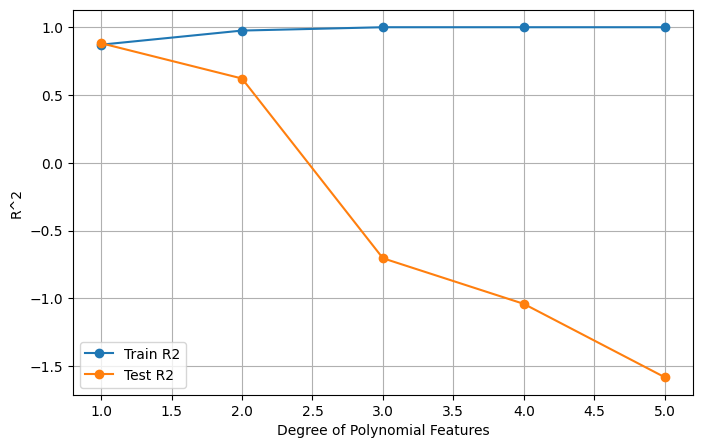

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1,6)
r2_train_list = []
r2_test_list = []

for degree in degrees:
   pipeline = Pipeline([
       ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
       ("linear_regression", LinearRegression())
   ])

   pipeline.fit(X_train, Y_train)

   y_train_pred = pipeline.predict(X_train)
   y_test_pred = pipeline.predict(X_test)

   r2_train_list.append(r2_score(Y_train, y_train_pred))
   r2_test_list.append(r2_score(Y_test, y_test_pred))

plt.figure(figsize = (8,5))
plt.plot(degrees, r2_train_list, marker ='o', label = "Train R2")
plt.plot(degrees, r2_test_list, marker = 'o', label = "Test R2")
plt.xlabel("Degree of Polynomial Features")
plt.ylabel("R^2")
plt.legend()
plt.grid(True)
plt.show()

На графике мы наблюдаем переобучение (overfitting) модели.

5. Построить модель с использованием регуляризации пример. На основе экспериментов подобрать параметры для регуляризации. Построить графики зависимости точности модели на обучающей и тестовой выборках от коэффициента регуляризации.

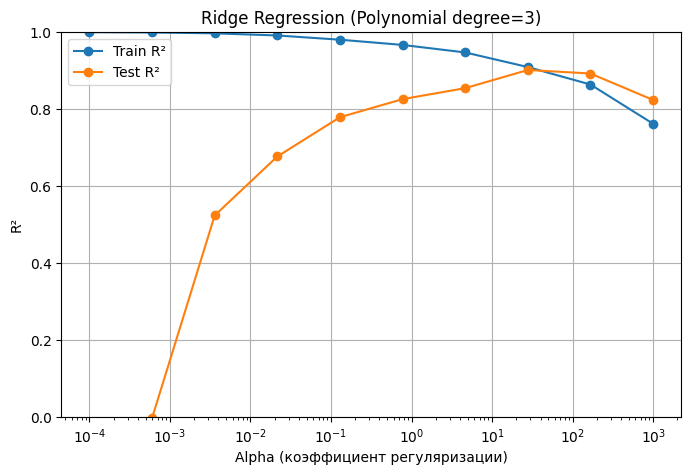

Наилучший alpha: 27.8256


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

degree = 3  # степень полинома
alphas = np.logspace(-4, 3, 10)  # диапазон коэффициентов регуляризации

r2_train_list = []
r2_test_list = []

for alpha in alphas:
    pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=alpha, max_iter=10000))
])

    # Обучаем модель на train
    pipeline.fit(X_train, Y_train)

    # Предсказания
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # R²
    r2_train_list.append(r2_score(Y_train, y_train_pred))
    r2_test_list.append(r2_score(Y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.semilogx(alphas, r2_train_list, marker='o', label="Train R²")
plt.semilogx(alphas, r2_test_list, marker='o', label="Test R²")
plt.xlabel("Alpha (коэффициент регуляризации)")
plt.ylabel("R²")
plt.title(f"Ridge Regression (Polynomial degree={degree})")
plt.ylim(0,1)  # шаг 0.2 можно регулировать через plt.yticks
plt.grid(True)
plt.legend()
plt.show()

best_index = np.argmax(r2_test_list)
best_alpha = alphas[best_index]

print(f"Наилучший alpha: {best_alpha:.4f}")

Для борьбы с переобучением и коррелированными признаками применим регуляризацию Ridge (L2). Она добавляет штраф к сумме квадратов коэффициентов модели, что стабилизирует обучение и уменьшает влияние сильно коррелированных признаков.

В качестве признаков используем полиномиальные признаки 3-й степени, как в предыдущем пункте (средняя точность и меньше затрат в вычислительной мощности). Обновим наш pipeline, который теперь выполняет следующие шаги:

PolynomialFeatures(degree=3, include_bias=False) – создаёт новые признаки, учитывающие комбинации и степени всех признаков (параметров смеси).

StandardScaler() – нормализует признаки. Это важно, так как L2-регуляризация чувствительна к масштабу признаков.

Ridge(alpha=α, max_iter=10000) – линейная регрессия с L2-регуляризацией. Параметр α контролирует силу штрафа: чем выше α, тем сильнее регуляризация и меньше риск переобучения.

Для подбора оптимального значения α выбираем диапазон от 10⁻⁴ до 10³ в логарифмической шкале.На графике можно увидеть, при каком αlpha модель лучше всего балансирует между переобучением и недообучением. Оптимальное значение α соответствует максимальному R² на тестовой выборке.
